In [1]:
import json
import glob
import os
import pandas as pd

from constant import WAF_NAMES, VALID_ATTACK_TYPES, SEEDS

CURRENT_DIR = os.path.abspath(".")
HARMFUL_DIRS = {
    "PHASE_1": os.path.join(CURRENT_DIR, "output_generate_phase1_harmful"),
    "PHASE_3": os.path.join(CURRENT_DIR, "output_generate_phase3_harmful"),
}
FILE_PREFIXES = {"PHASE_1": "phase1", "PHASE_3": "phase3"}


def load_records(jsonl_path):
    records = []
    if not os.path.exists(jsonl_path):
        return records
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records


def get_is_bypassed(record):
    # phase1 keeps the original nested attack_result (is_bypassed at top level
    # is left as None); phase3 already has is_bypassed flattened.
    attack_result = record.get("attack_result")
    if attack_result is not None:
        return attack_result.get("is_bypassed")
    return record.get("is_bypassed")


In [2]:
# Aggregate: waf -> attack_type -> phase -> seed -> {safe_blocked, harm_blocked, safe_bypassed, harm_bypassed, total_payload}
general_result = {}

for waf_name in WAF_NAMES:
    general_result[waf_name] = {}
    for attack_type in VALID_ATTACK_TYPES:
        general_result[waf_name][attack_type] = {}
        for phase in ["PHASE_1", "PHASE_3"]:
            prefix = FILE_PREFIXES[phase]
            jsonl_path = os.path.join(HARMFUL_DIRS[phase], f"{prefix}.{waf_name}.{attack_type}.jsonl")
            records = load_records(jsonl_path)

            by_seed = {}
            for record in records:
                seed = record.get("seed")
                is_bypassed = get_is_bypassed(record)
                is_harmful = record.get("is_harmful")
                if seed not in by_seed:
                    by_seed[seed] = {
                        "safe_blocked": 0,
                        "harm_blocked": 0,
                        "safe_bypassed": 0,
                        "harm_bypassed": 0,
                        "total_payload": 0,
                    }
                by_seed[seed]["total_payload"] += 1
                if is_bypassed:
                    by_seed[seed]["harm_bypassed" if is_harmful else "safe_bypassed"] += 1
                else:
                    by_seed[seed]["harm_blocked" if is_harmful else "safe_blocked"] += 1

            general_result[waf_name][attack_type][phase] = by_seed

print("Loaded. Example (AWS, sql_injection, PHASE_1):")
general_result["AWS"]["sql_injection"]["PHASE_1"]

Loaded. Example (AWS, sql_injection, PHASE_1):


{123: {'safe_blocked': 0,
  'harm_blocked': 0,
  'safe_bypassed': 18,
  'harm_bypassed': 32,
  'total_payload': 50},
 42: {'safe_blocked': 0,
  'harm_blocked': 0,
  'safe_bypassed': 23,
  'harm_bypassed': 27,
  'total_payload': 50},
 999: {'safe_blocked': 0,
  'harm_blocked': 0,
  'safe_bypassed': 14,
  'harm_bypassed': 36,
  'total_payload': 50},
 2024: {'safe_blocked': 0,
  'harm_blocked': 0,
  'safe_bypassed': 15,
  'harm_bypassed': 35,
  'total_payload': 50},
 777: {'safe_blocked': 0,
  'harm_blocked': 0,
  'safe_bypassed': 23,
  'harm_bypassed': 27,
  'total_payload': 50}}

In [3]:
import matplotlib.pyplot as plt
import numpy as np


def get_counts(waf_name, attack_type, phase, seed):
    by_seed = general_result.get(waf_name, {}).get(attack_type, {}).get(phase, {})
    return by_seed.get(seed, {
        "safe_blocked": 0,
        "harm_blocked": 0,
        "safe_bypassed": 0,
        "harm_bypassed": 0,
        "total_payload": 0,
    })


def plot_waf_for_seed(waf_name, seed, ax=None):
    """Same stacked-bar design as the earlier defend_test_2026_04_21 notebook:
    x = attack_type, each column split into PHASE_1 (RD) / PHASE_3 (AD) bars,
    each bar stacked as safe_blocked / harm_blocked / safe_bypassed / harm_bypassed."""
    phases = ['PHASE_1', 'PHASE_3']
    attack_types = VALID_ATTACK_TYPES

    x = np.arange(len(attack_types))
    width = 0.30

    bars_phase = {}
    for phase in phases:
        counts = [get_counts(waf_name, attack_type, phase, seed) for attack_type in attack_types]
        bars_phase[phase] = {
            'safe_blocked': np.array([c['safe_blocked'] for c in counts]),
            'harm_blocked': np.array([c['harm_blocked'] for c in counts]),
            'safe_bypassed': np.array([c['safe_bypassed'] for c in counts]),
            'harm_bypassed': np.array([c['harm_bypassed'] for c in counts]),
            'total_payload': np.array([c['total_payload'] for c in counts]),
        }

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 5))

    colors = ['#814CAF', '#1A9F2C', '#E3B13D', '#FF0000']
    labels = ['Safe Blocked', 'Harm Blocked', 'Safe Bypassed', 'Harm Bypassed']
    keys = ['safe_blocked', 'harm_blocked', 'safe_bypassed', 'harm_bypassed']

    for phase in phases:
        offset = -(width / 2 + 0.01) if phase == 'PHASE_1' else (width / 2 + 0.01)
        safe_blocked = bars_phase[phase]['safe_blocked']
        harm_blocked = bars_phase[phase]['harm_blocked']
        safe_bypassed = bars_phase[phase]['safe_bypassed']
        harm_bypassed = bars_phase[phase]['harm_bypassed']
        total_payload = bars_phase[phase]['total_payload']
        stacks = [safe_blocked, harm_blocked, safe_bypassed, harm_bypassed]

        bottom = np.zeros(len(attack_types))
        for key, color, label, values in zip(keys, colors, labels, stacks):
            show_label = label if phase == 'PHASE_1' else None
            ax.bar(x + offset, values, width, bottom=bottom, label=show_label, color=color)
            bottom += values

        for j in range(len(attack_types)):
            total = total_payload[j] if total_payload[j] > 0 else 1
            y_offset = 0
            for val in [safe_blocked[j], harm_blocked[j], safe_bypassed[j], harm_bypassed[j]]:
                if val > 0:
                    percent = val * 100 / total
                    ax.text(x[j] + offset, y_offset + val / 2, f'{percent:.0f}%', ha='center', va='center', fontsize=7, color='black')
                y_offset += val
            phase_text = 'RD' if phase == 'PHASE_1' else 'AD'
            max_height = safe_blocked[j] + harm_blocked[j] + safe_bypassed[j] + harm_bypassed[j]
            ax.text(x[j] + offset, max_height, phase_text, ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    ax.set_ylabel('Number of Payloads')
    ax.set_title(f'{waf_name} - seed={seed}', y=1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([attack_type.replace('sql_injection', 'sqli') for attack_type in attack_types], rotation=0, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    if own_fig:
        ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
        fig.subplots_adjust(bottom=0.18)
        fig.align_xlabels()
        plt.show()

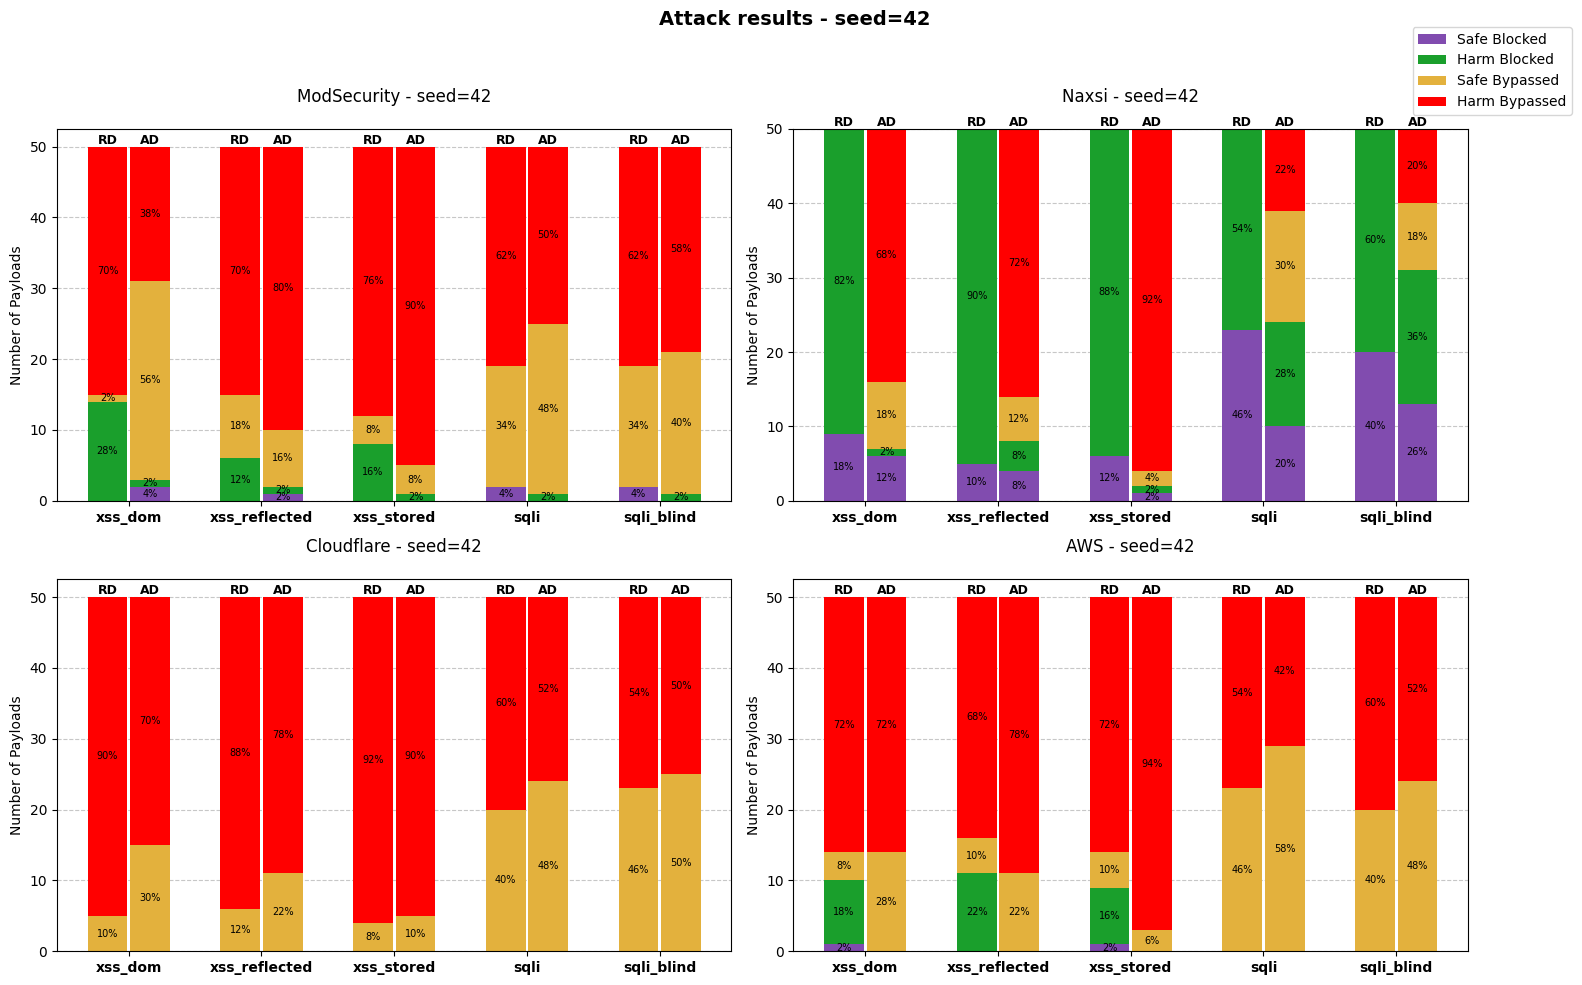

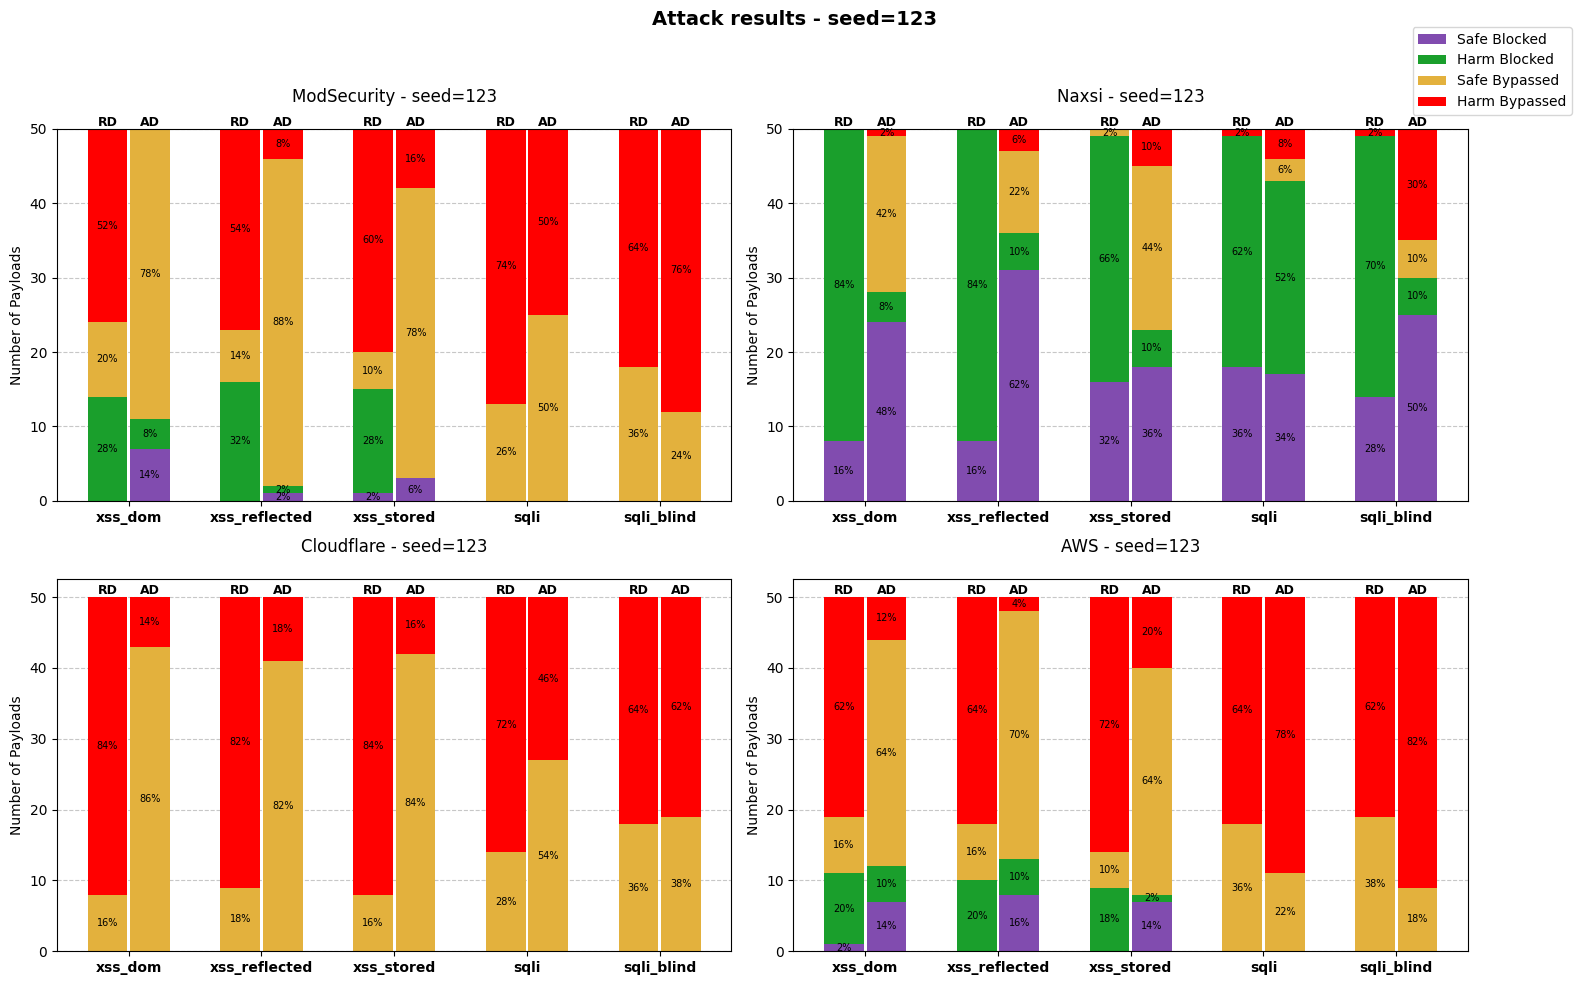

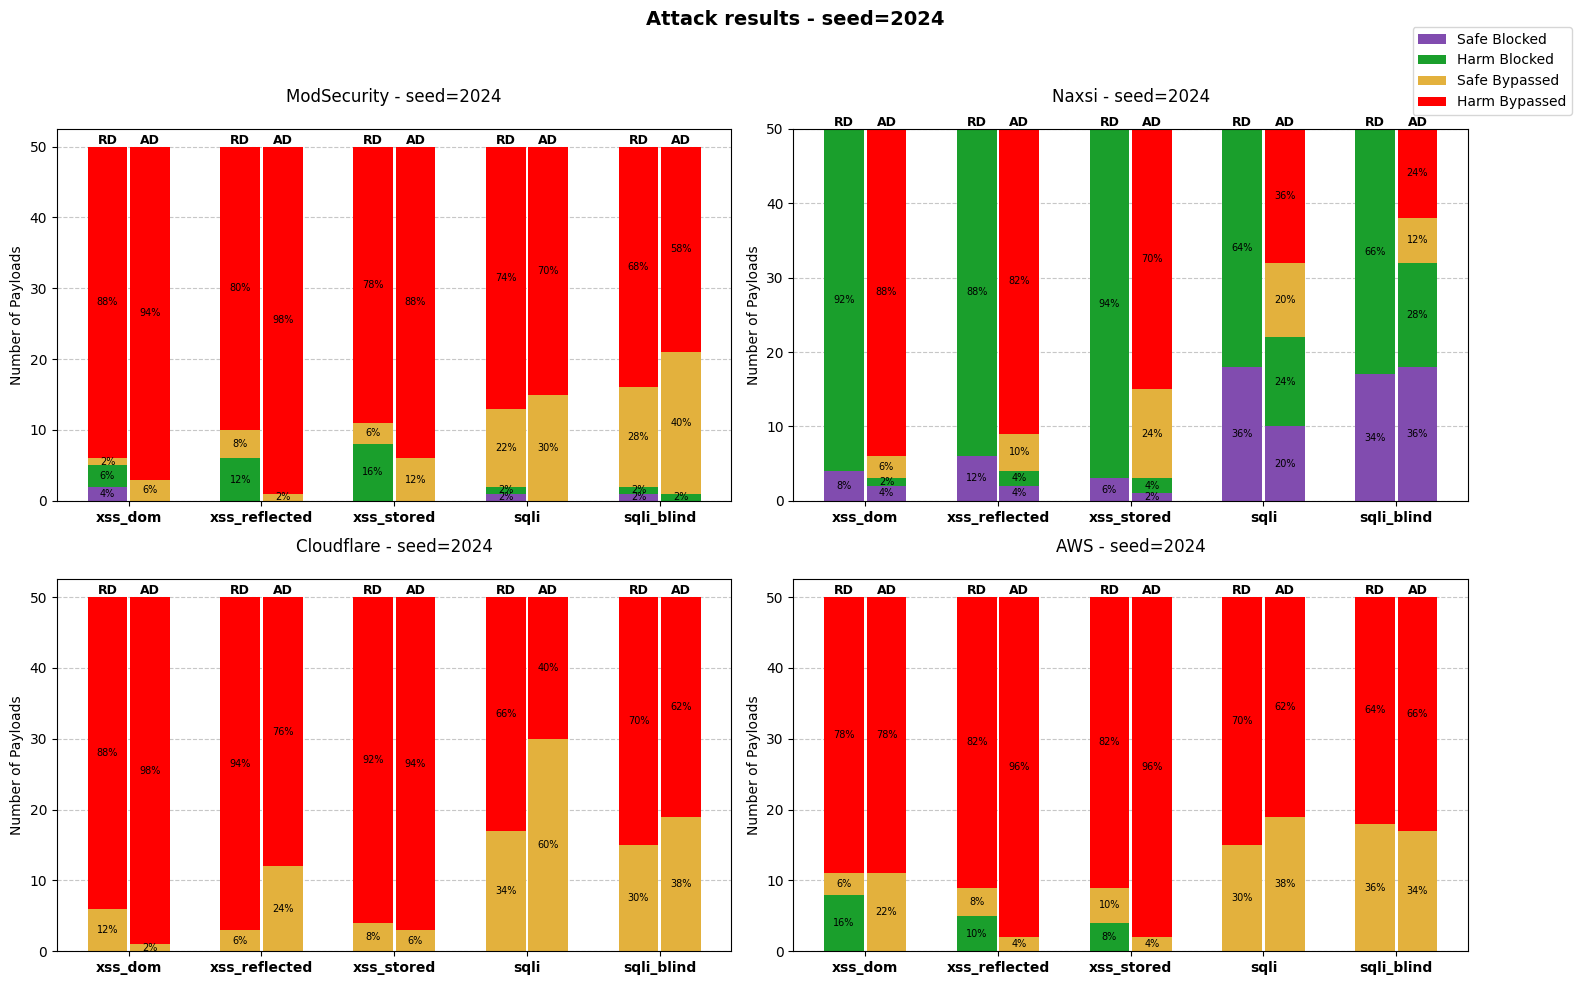

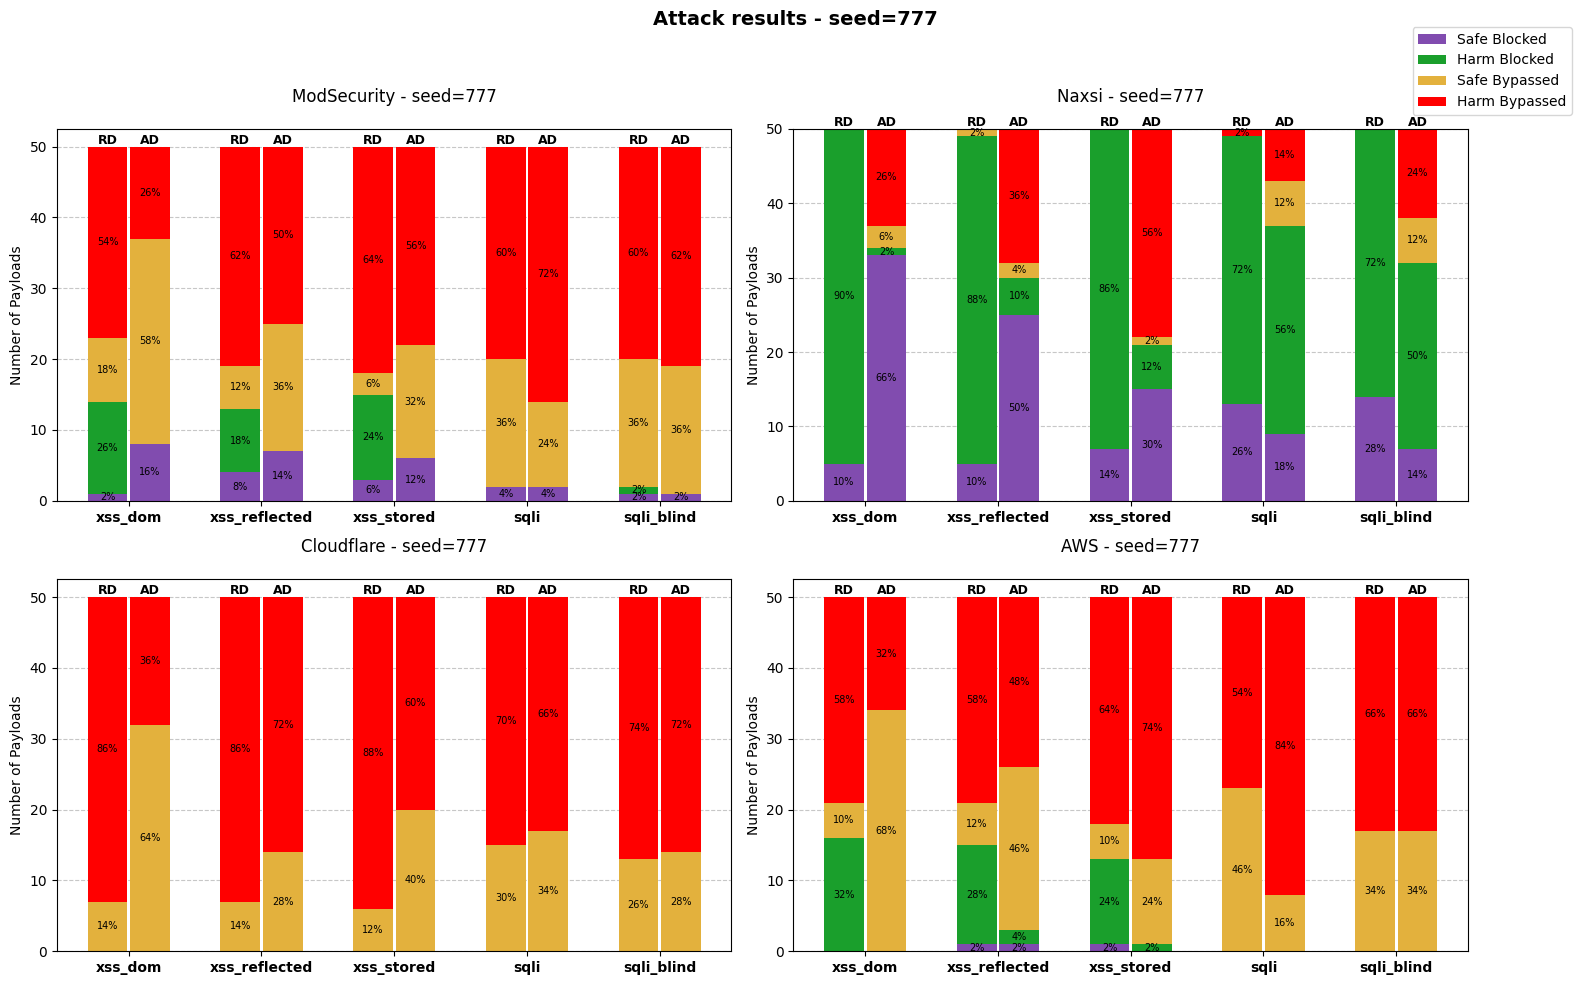

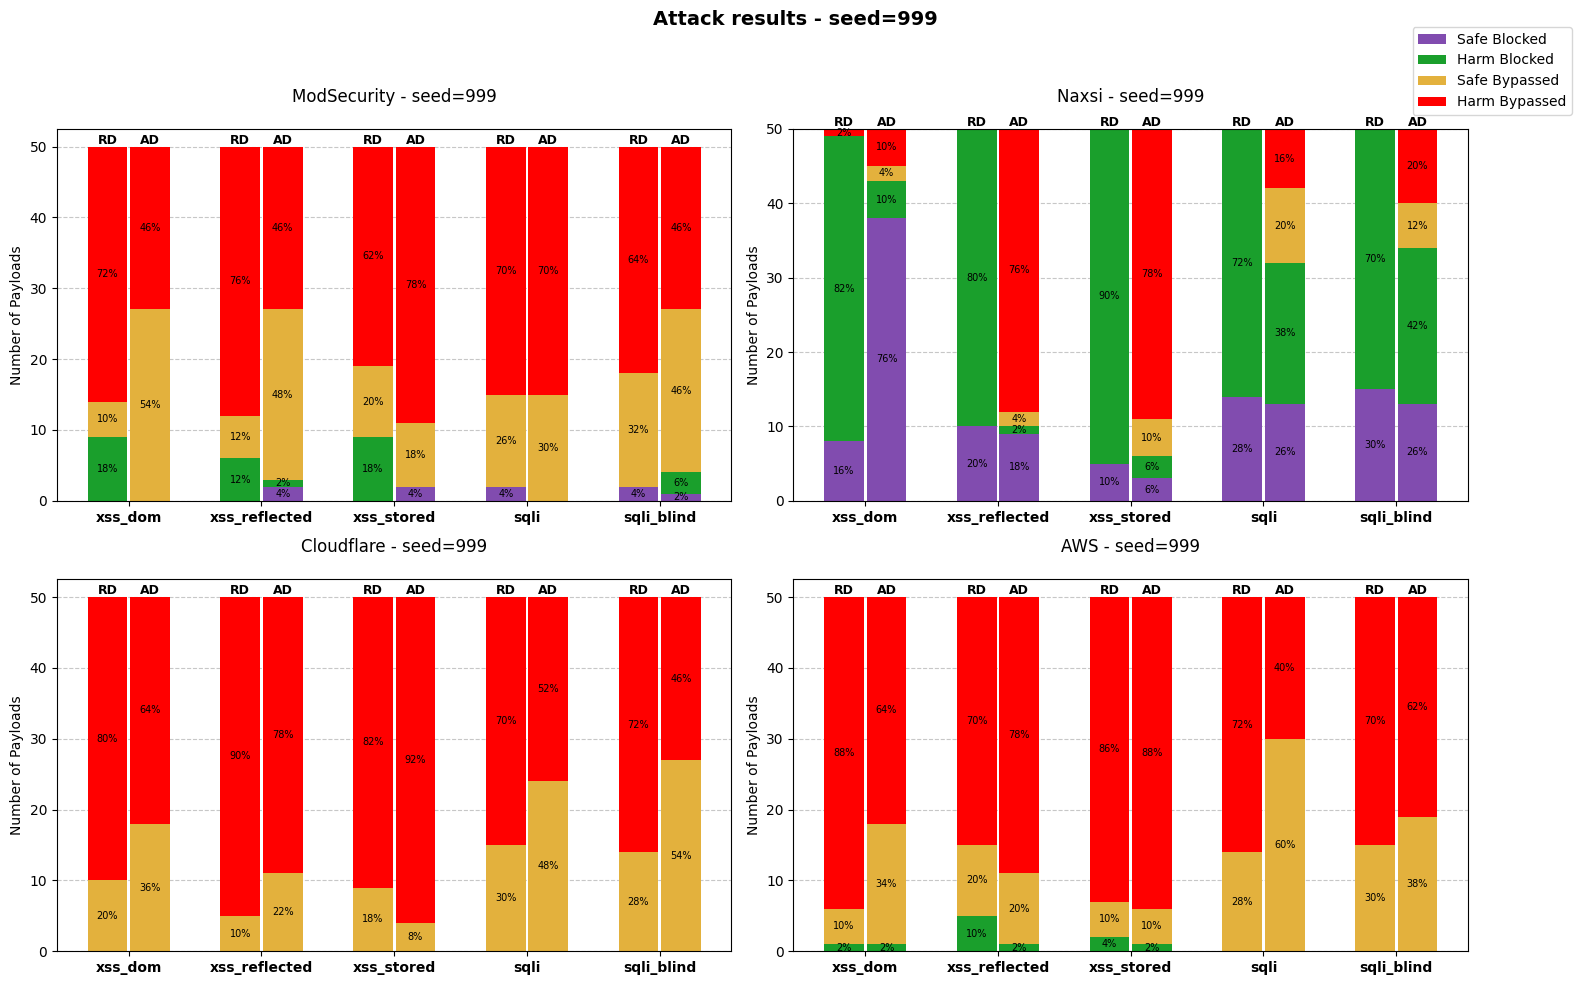

In [4]:
# One figure per seed, with a 2x2 grid of subplots (one per WAF).
for seed in SEEDS:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Attack results - seed={seed}', fontsize=14, fontweight='bold')

    for ax, waf_name in zip(axes.flat, WAF_NAMES):
        plot_waf_for_seed(waf_name, seed, ax=ax)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.97))
    fig.tight_layout(rect=[0, 0, 0.93, 0.95])
    plt.show()